# CODE-DE-LAB Datenzugang vom Jupyter-Lab über BOTO3
**Copyright:** © 2026 Urbetho CF GmbH
**Lizenz:** Dieses Notebook steht unter der [CC BY-NC-SA 4.0 License](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.en).

<div style="text-align: right"><i> Anfänger*innen </i></div>

Wir verwenden den Zugang aus dem JupyterLab, um auf Daten des Copernicus-Landdienstes zugreifen zu können. In diesem Fall nutzen wir die europaweite **CORINE Land Cover Plus Land Use, Land-Use Change and Forestry Instance** (CLCplus LULUCF Instance) für 2023, die eine pan-europäische, räumlich konsistente und nahtlose Grundlage für die Landnutzungsberichterstattung (*land use reporting*) unter der LULUCF-Verordnung bietet. 

**Hinweis 1:** Führe eine Zelle durch Klicken auf den <kbd>▶</kbd> **Play-Button** im oberen Menü aus (oder drücke `Shift` + `Enter`).

**Hinweis 2:** Falls der Kernel hängt, klicke im oberen Menü auf den <kbd>↻</kbd> **Restart-Button**. Klicke danach im Menü auf **Run** und wähle **Run All Above Selected Cell**.

**Hinweis 3:** Schau dich im [**FORUM**](https://forum.code-de.org/de/) um oder kontaktiere den Support!

In [5]:
%pip install numpy rasterio boto3 matplotlib pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [33]:
#import required libraries
import rasterio
from rasterio import plot
import boto3
import os
import numpy
import getpass
import pandas as pd

In [16]:
# access CODE-DE-Lab S3 endpoint (setup the keys in the "EODATA Access" section in your CODE-DE-Lab profile)

access_key = input("Enter your access key: ")
secret_key = getpass.getpass("Enter your secret key: ")

host='http://eodata.code-de.org'
s3=boto3.client('s3',aws_access_key_id=access_key, aws_secret_access_key=secret_key, endpoint_url=host,)
print('Connecting to CODE-DE-Lab')

Connecting to CODE-DE-Lab


In [17]:
response = s3.list_buckets()

# Überprüfen, ob Buckets vorhanden sind
if 'Buckets' in response:
    # Durch jeden Bucket iterieren und den Namen ausgeben
    print("I found the following bucket:")
    for bucket in response['Buckets']:
        print(bucket['Name'])
else:
    print("No buckets avabiable or no access.")


# Objekte im Bucket auflisten
response = s3.list_objects_v2(Bucket='eodata')
    
# Dateien ohne Unterordner anzeigen
if 'CommonPrefixes' in response:
        print("Kollektionen:")
        for obj in response['CommonPrefixes']:
            print(obj['Prefix'])
else:
        print("Keine Dateien im Bucket gefunden.")



I found the following bucket:
eodata
Kollektionen:
Aqua/
BKG-PlanetScope/
BKG-RapidEye/
BKG-SPOT/
C3S/
CAMS/
CEMS/
CLMS/
CLMS_archive/
DAQA/
ENMAP/
Envisat-ASAR/
Global-Mosaics/
Jason-3/
Landsat-5/
Landsat-7/
Landsat-8/
Landsat-9/
PLANET-PlanetScope/
PLANET-PlanetScopeMosaics/
RESA-PlanetScope/
RESA-RapidEye/
RESA-SkySat/
RapidEye-DE/
SMOS/
SRTM/
Sentinel-1-RTC/
Sentinel-1/
Sentinel-2/
Sentinel-3/
Sentinel-5P/
Sentinel-6/
Suomi-NPP/
TDM-FNF-50/
Terra/
TerraAqua/
auxdata/
codede-aerial-surveys/
codede-reference-data/
codede-thematic-data/
constellr/
ororatech/


Jetz wissen wir was es an Datensätze gibt auf CODE-DE-Lab. Mit dem Besipiel kann eine weitere Datensuche erfolgen - oder auch über die REST API.
Wir schauen uns Daten im Copernicus Landdienst an...

In [25]:
# now lets have a closer look inside CLMS
prefix = 'CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/'
response = s3.list_objects_v2(Bucket='eodata', Prefix=prefix, Delimiter='/')
    
# Dateien ohne Unterordner anzeigen
flist=[]
if 'Contents' in response:
        print("Dateien im Bucket:")
        for obj in response['Contents']:
            print(obj['Key'])
            flist.append(obj['Key'])
else:
        print("Keine Dateien im Bucket gefunden.") 

Dateien im Bucket:
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00.tif
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00.xml


Wir kopieren die europaweite CLCplus LULUCF Instace-Datei für 2023 lokal in unserer Ordner - 200 MB.

In [26]:
fLocal = os.path.basename(flist[0])
    
with open(fLocal, 'wb') as data:
        s3.download_fileobj('eodata',flist[0], data) 

Dies ist ein graustufen TIF der 65000 x 46000 Pixeln. Wir plotten "nur" ein keines Subset mit einer Farbtafel um erst einmal etwas zu sehen.
Mehr Informationen über die CLMS CLCplus LULUCF Instance gibt es hier: https://browser.stac.dataspace.copernicus.eu/collections/clms_clcplus_lulucf-instance_europe_100m_yearly_v1

Dateiname: CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00.tif
Dies is nur ein Beispiel-Plot der Raster Daten. Die CLC Farbcodierung steht in: CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/clms_clcplus_lulucf-instance_europe_100m_yearly_v1.clr


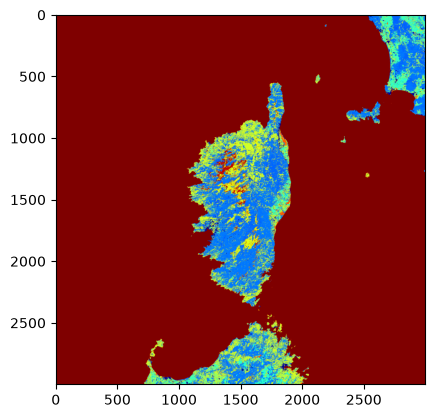

<Axes: >

In [27]:
src = rasterio.open(fLocal)
# read a subset only
data_subset = src.read(window=((31500,34500),(31500,34500)))
print("Dateiname:", fLocal)
print("Dies is nur ein Beispiel-Plot der Raster Daten. Die CLC Farbcodierung steht in:", flist2[0])

plot.show(data_subset,cmap='jet',vmin=11,vmax=64)


In [28]:
#delete the downloaded file
src.close()
os.remove(fLocal)

In [34]:
# now lets have (again) a closer look inside CLMS. But this time we look into the data collection "Legend"
prefix = 'CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/'
response = s3.list_objects_v2(Bucket='eodata', Prefix=prefix, Delimiter='/')
    
# Show files without subcollections
flist2=[]
if 'Contents' in response:
        print("Dateien im Bucket:")
        for obj in response['Contents']:
            print(obj['Key'])
            flist2.append(obj['Key'])
else:
        print("Keine Dateien im Bucket gefunden.") 

Dateien im Bucket:
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/clms_clcplus_lulucf-instance_europe_100m_yearly_v1.clr
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/clms_clcplus_lulucf-instance_europe_100m_yearly_v1.lyrx
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/clms_clcplus_lulucf-instance_europe_100m_yearly_v1.qml
CLMS/landcover_landuse/clcplus_instance/clms_clcplus_lulucf-instance_europe_100m_yearly_v1/2023/01/01/CLMS_CLCPLUS_LULUCF-INSTANCE_S2023_R100m_EUROPE_03035_V01_R00/Legend/clms_clcplus_lulucf-instance_europe_100m_yearly_v1.sld


In der "Legend" Kollektion sehen wir Datein, die wir nutzen können, um die Rasterdatei nach den offiziellen Vorgaben farblich darzustellen. Außerdem können wir uns auch ausgeben, welche Klasse mit welchem numerischen Wert verknüpft ist.

In [31]:
fLocal = os.path.basename(flist2[0])
    
with open(fLocal, 'wb') as data:
        s3.download_fileobj('eodata',flist2[0], data) 

Wir geben uns nun die Colorcodes und die Klassennamen und zugehörigen Klassencodes aus. Basierend darauf können wir unsere Karte dann mit einer Legende versehen.

In [37]:
rows = []
with open(fLocal, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # maxsplit=5 teilt streng nur die ersten 5 Werte ab (COPERNICUS, R, G, B, A)
        parts = line.split(maxsplit=5)
        if len(parts) >= 5:
            rows.append({
                #'COPERNICUS': int(parts[0]),
                'R': int(parts[1]),
                'G': int(parts[2]),
                'B': int(parts[3]),
                'A': int(parts[4]),
                'Name': parts[5] if len(parts) > 5 else ''
            })

leg = pd.DataFrame(rows)
leg

,R,G,B,A,Name
0,91,12,1,255,11: S Burnt areas
1,191,2,40,255,12: S Settlements
2,244,38,54,255,13: S Green urban areas
3,255,107,33,255,14: S Other settlements
4,16,29,16,255,21: FL Burnt areas
5,1,42,15,255,22: FL Transitional woodland
6,2,62,22,255,23: FL Deciduous
7,4,85,31,255,24: FL Coniferous/Evergreen
8,5,117,42,255,25: FL Other forestland
9,126,124,17,255,31: CL Burnt areas


In [49]:
#removing the txt file
os.remove(fLocal)